In [1]:
import pandas as pd
import numpy as np

from google.colab import drive

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn import ensemble
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

from sklearn import metrics
import math

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path='/content/drive/MyDrive/ChronicKidneyDisease.csv'
df=pd.read_csv(file_path)
print(df)

       Bp     Sg   Al   Su  Rbc    Bu   Sc     Sod   Pot  Hemo    Wbcc  Rbcc  \
0    80.0  1.020  1.0  0.0  1.0  36.0  1.2  137.53  4.63  15.4  7800.0  5.20   
1    50.0  1.020  4.0  0.0  1.0  18.0  0.8  137.53  4.63  11.3  6000.0  4.71   
2    80.0  1.010  2.0  3.0  1.0  53.0  1.8  137.53  4.63   9.6  7500.0  4.71   
3    70.0  1.005  4.0  0.0  1.0  56.0  3.8  111.00  2.50  11.2  6700.0  3.90   
4    80.0  1.010  2.0  0.0  1.0  26.0  1.4  137.53  4.63  11.6  7300.0  4.60   
..    ...    ...  ...  ...  ...   ...  ...     ...   ...   ...     ...   ...   
395  80.0  1.020  0.0  0.0  1.0  49.0  0.5  150.00  4.90  15.7  6700.0  4.90   
396  70.0  1.025  0.0  0.0  1.0  31.0  1.2  141.00  3.50  16.5  7800.0  6.20   
397  80.0  1.020  0.0  0.0  1.0  26.0  0.6  137.00  4.40  15.8  6600.0  5.40   
398  60.0  1.025  0.0  0.0  1.0  50.0  1.0  135.00  4.90  14.2  7200.0  5.90   
399  80.0  1.025  0.0  0.0  1.0  18.0  1.1  141.00  3.50  15.8  6800.0  6.10   

     Htn  Class  
0    1.0      1  
1  

In [4]:
df.head()
df.shape

(400, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Bp      400 non-null    float64
 1   Sg      400 non-null    float64
 2   Al      400 non-null    float64
 3   Su      400 non-null    float64
 4   Rbc     400 non-null    float64
 5   Bu      400 non-null    float64
 6   Sc      400 non-null    float64
 7   Sod     400 non-null    float64
 8   Pot     400 non-null    float64
 9   Hemo    400 non-null    float64
 10  Wbcc    400 non-null    float64
 11  Rbcc    400 non-null    float64
 12  Htn     400 non-null    float64
 13  Class   400 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 43.9 KB


In [5]:
df.isnull().sum()

,0
Bp,0
Sg,0
Al,0
Su,0
Rbc,0
Bu,0
Sc,0
Sod,0
Pot,0
Hemo,0


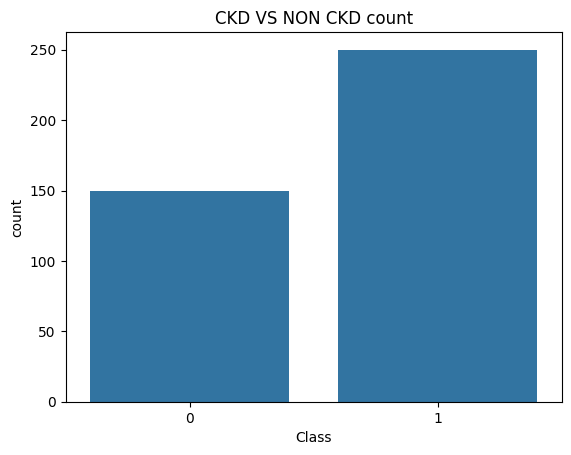

In [6]:
sns.countplot(data=df,x='Class')
plt.title('CKD VS NON CKD count')
plt.show()

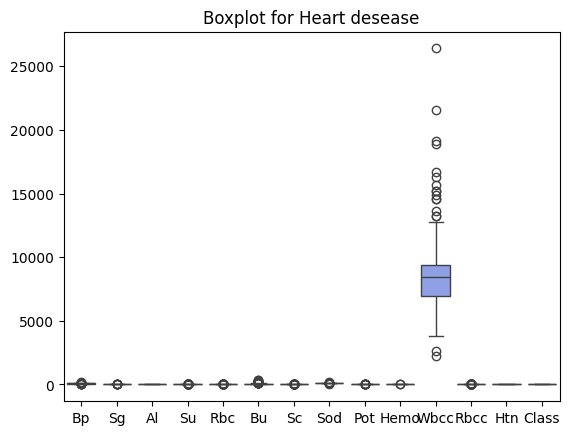

In [7]:
sns.boxplot(data=df )
plt.title('Boxplot for Heart desease')
plt.show()

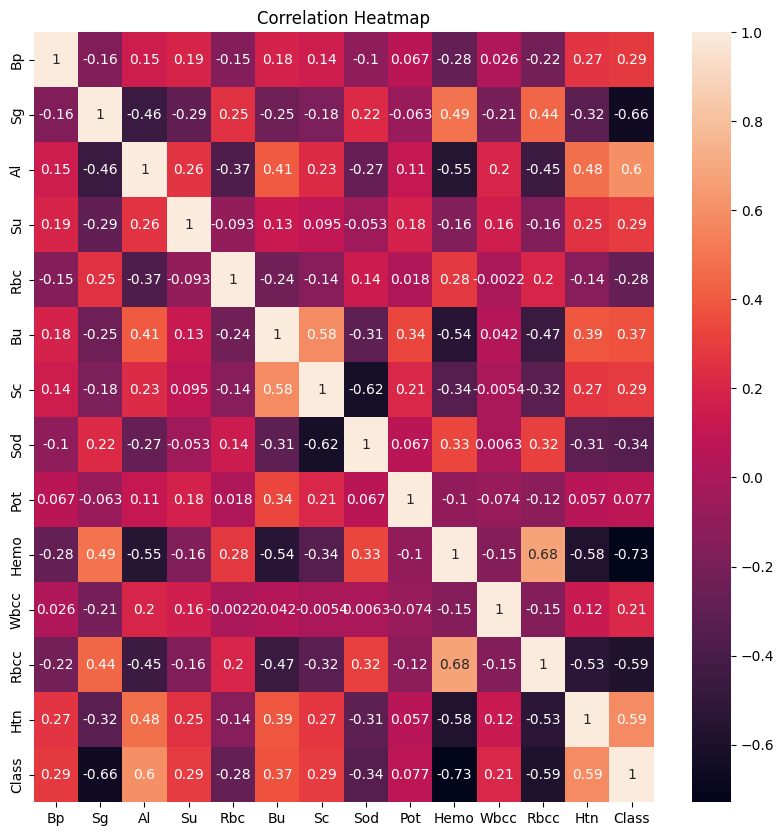

In [8]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot=True)
plt.title('Correlation Heatmap')
plt.show()

In [9]:
x=df.drop('Class',axis=1)
y=df['Class']

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

rf=ensemble.RandomForestClassifier(random_state=0)
rf.fit(x_train,y_train)

lr=LogisticRegression()
lr.fit(x_train,y_train)

rf=DecisionTreeClassifier()
rf.fit(x_train,y_train)

rf=KNeighborsClassifier()
rf.fit(x_train,y_train)

rf=SVC()
rf.fit(x_train,y_train)

SVC()

In [20]:
y_pred=rf.predict(x_test)
y_pred
y_pred_lr=lr.predict(x_test)
y_pred_lr
y_pred_dt=rf.predict(x_test)
y_pred_dt
y_pred_knn=rf.predict(x_test)
y_pred_knn
y_pred_svm=rf.predict(x_test)
y_pred_svm

array([1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0])

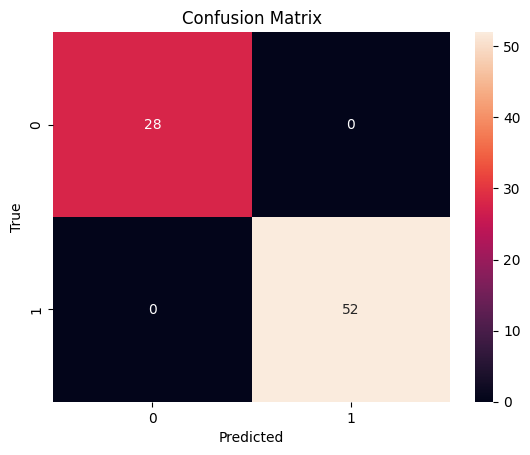

In [21]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

Random Forest 1.0
Logitistic Regression 1.0
Decision Tree 1.0
KNN 1.0
SVM 1.0


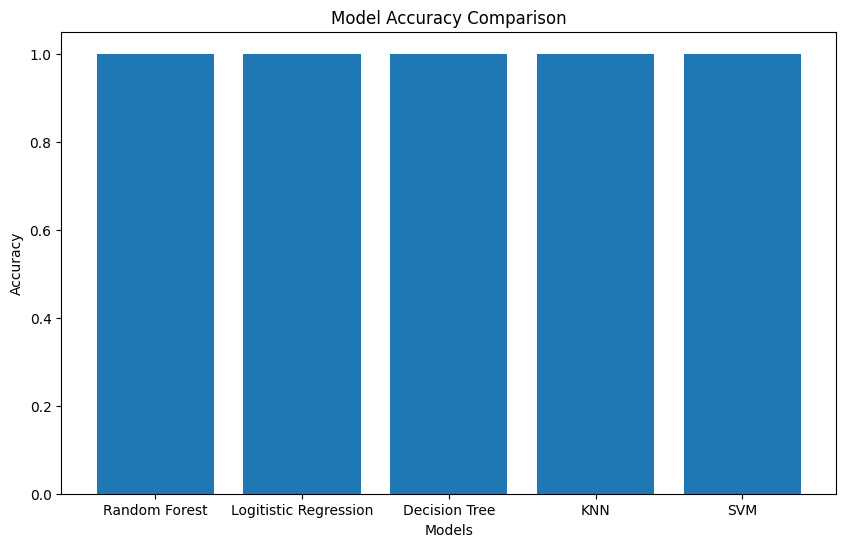

Best Model: Random Forest


In [25]:
import sklearn as sk
from sklearn.metrics import accuracy_score
print('Random Forest', accuracy_score(y_test, y_pred))
print('Logitistic Regression', accuracy_score(y_test, y_pred_lr))
print('Decision Tree', accuracy_score(y_test, y_pred_dt))
print('KNN', accuracy_score(y_test, y_pred_knn))
print('SVM', accuracy_score(y_test, y_pred_svm))
model_accuracy = {
    'Random Forest': accuracy_score(y_test, y_pred),
    'Logitistic Regression': accuracy_score(y_test, y_pred_lr),
    'Decision Tree': accuracy_score(y_test, y_pred_dt),
    'KNN': accuracy_score(y_test, y_pred_knn),
    'SVM': accuracy_score(y_test, y_pred_svm)
}
plt.figure(figsize=(10,6))
plt.bar(model_accuracy.keys(), model_accuracy.values())
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.show()
best_model = max(model_accuracy, key=model_accuracy.get)
print("Best Model:", best_model)

In [23]:
def predict_outcome():
  featuress=[]
  for col in x.columns:
    value=float(input(f"Enter the value for {col}: "))
    featuress.append(value)

  featuress=np.array(featuress).reshape(1,-1)
  featuress=scaler.transform(featuress)
  prediction=rf.predict(featuress)
  if (prediction[0]==1):
    print("CHRONIC KIDNEY DISEASE +POSITIVE")
  else :
    print("CHRONIC KIDNEY DISEASE -NEGATIVE")

In [16]:
predict_outcome()

Enter the value for Bp: 80
Enter the value for Sg: 1.020
Enter the value for Al: 1
Enter the value for Su: 0
Enter the value for Rbc: 5.2
Enter the value for Bu: 36
Enter the value for Sc: 1.2
Enter the value for Sod: 135
Enter the value for Pot: 4.5
Enter the value for Hemo: 15.4
Enter the value for Wbcc: 7800
Enter the value for Rbcc: 5.2
Enter the value for Htn: 15
CHRONIC KIDNEY DESEASE +POSITIVE


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
